# CSC 405 Final Project  
## Dirty Iranian Transactions Dataset

This notebook analyzes transaction data and focuses on predicting whether a transaction will succeed or fail.

In [27]:
import pandas as pd
import numpy as np

In [28]:
df = pd.read_csv("../data/trx-10k.csv")
df.head()

,status,time,card_type,city,amount,id
0,success,2025-09-07 10:48:00,Visa,Tehran,1427657.0,98
1,success,2025-09-20 13:10:00,MastCard,Tehran,1578078.0,52
2,fail,2025-09-29 03:27:00,Visa,Tehran,250000.0,20
3,success,2025-09-15 13:13:00,Discover,Isfahan,0.0,40
4,success,2025-09-11 11:11:00,Visa,Tehran,1782689.0,59


# Part 1: Data Cleaning

The dataset has inconsistent values in the status column, so we clean them before analysis.

In [30]:
df["status"] = df["status"].str.lower()

df["status"] = df["status"].replace({
    "failed": "fail",
    "succeed": "success"
})

df["status"].value_counts()

status
fail       5366
success    4634
Name: count, dtype: int64

# Part 2: Exploratory Data Analysis (EDA)

Next, we explore the dataset using summary statistics and transaction patterns.

In [31]:
df.describe()

,amount,id
count,1.000000e+04,10000.000000
mean,2.954735e+08,50.061200
std,1.692035e+09,28.870875
min,-9.999990e+05,1.000000
25%,1.005000e+02,25.000000
50%,3.436790e+05,50.000000
75%,9.144650e+05,74.000000
max,1.000000e+10,100.000000


In [32]:
df["city"].value_counts().head(10)

city
Tehran     2063
Tabriz     1368
Isfahan    1073
Mashhad     900
Shiraz      727
Qom         669
Karaj       642
Ahvaz       632
THR         409
TEHRAN      403
Name: count, dtype: int64

# Visualization

The charts below help show important patterns in the transaction data.

In [33]:
import matplotlib.pyplot as plt

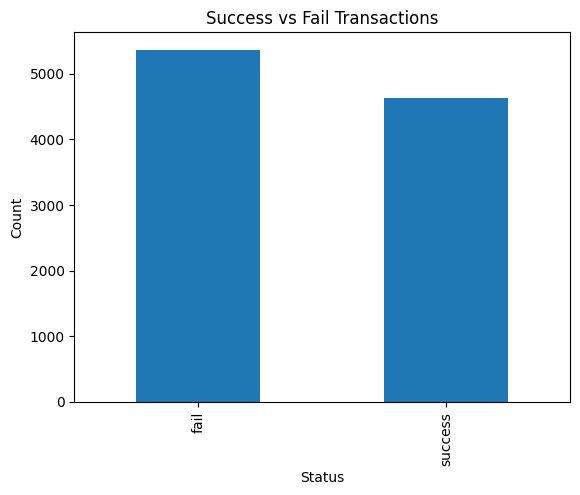

In [34]:
df["status"].value_counts().plot(kind="bar")
plt.title("Success vs Fail Transactions")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

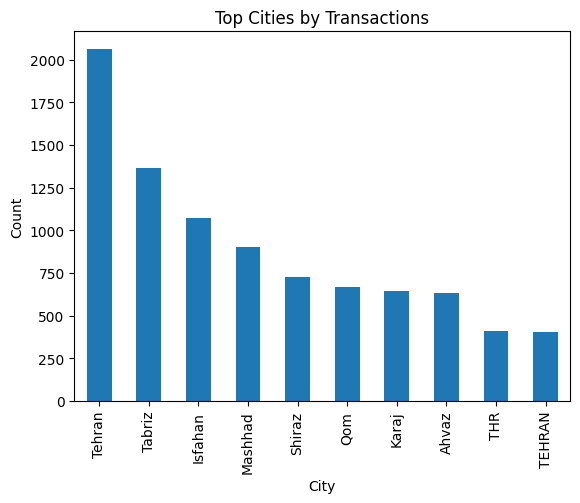

In [35]:
df["city"].value_counts().head(10).plot(kind="bar")
plt.title("Top Cities by Transactions")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

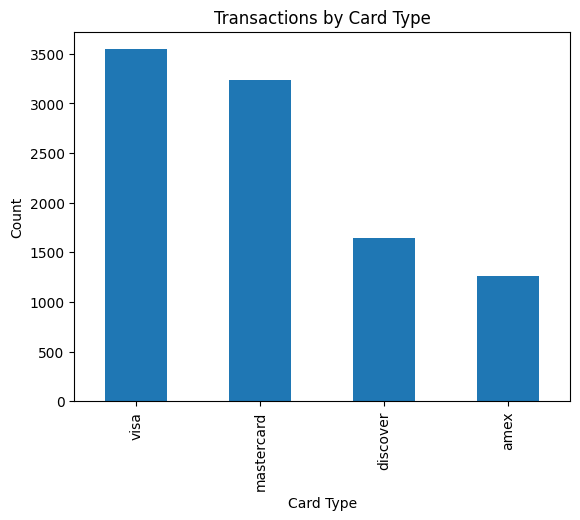

In [55]:
df["card_type"].value_counts().plot(kind="bar")
plt.title("Transactions by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Count")
plt.show()

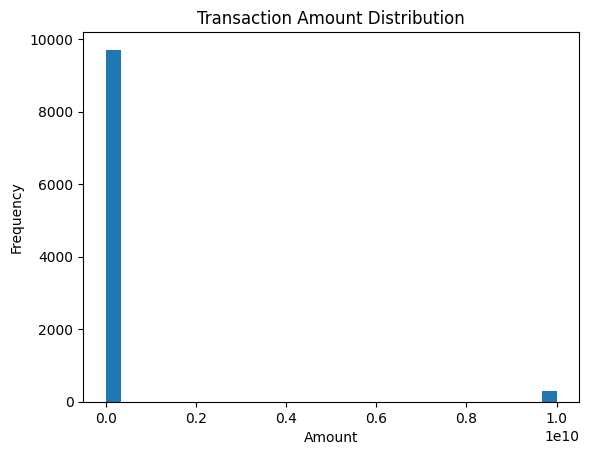

In [56]:
df["amount"].plot(kind="hist", bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Part 3: Statistical Analysis

We compare the average transaction amount for successful and failed transactions.

In [36]:
success_amt = df[df["status"] == "success"]["amount"]
fail_amt = df[df["status"] == "fail"]["amount"]

print("Average Success Amount:", success_amt.mean())
print("Average Fail Amount:", fail_amt.mean())

Average Success Amount: 233535316.81063876
Average Fail Amount: 348962343.9617033


**Null Hypothesis:** The average transaction amount is the same for successful and failed transactions.

The average failed transaction amount was higher than the average successful transaction amount. This suggests transaction amount may be related to whether a payment succeeds or fails.

# Part 4: Data Modeling

This section uses transaction features to test whether we can identify risky or dangerous transaction patterns.

The main features used are transaction amount, city, card type, and time of transaction.

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import pearsonr, chi2_contingency
import seaborn as sns

## Preparing Features

Before modeling, we clean city names and card types again so the model does not treat spelling mistakes as separate categories.
We also create an hour column from the time column.

In [58]:
df["city"] = df["city"].str.lower().str.strip()
df["card_type"] = df["card_type"].str.lower().str.strip()

df["city"] = df["city"].replace({
    "tehr@n": "tehran",
    "thr": "tehran",
    "thran": "tehran",
    "tehran ": "tehran"
})

df["card_type"] = df["card_type"].replace({
    "mastcard": "mastercard",
    "master card": "mastercard",
    "master-card": "mastercard",
    "vsa": "visa"
})

df["time"] = pd.to_datetime(df["time"])
df["hour"] = df["time"].dt.hour

df[["status", "time", "hour", "card_type", "city", "amount"]].head()

,status,time,hour,card_type,city,amount
0,success,2025-09-07 10:48:00,10,visa,tehran,1427657.0
1,success,2025-09-20 13:10:00,13,mastercard,tehran,1578078.0
2,fail,2025-09-29 03:27:00,3,visa,tehran,250000.0
3,success,2025-09-15 13:13:00,13,discover,isfahan,0.0
4,success,2025-09-11 11:11:00,11,visa,tehran,1782689.0


## Correlation and P-Values

To connect the model to our project question, we test whether relevant features are related to transaction status.

Null hypothesis: The feature is not related to transaction status.

If the p-value is small, that suggests the feature may have a relationship with transaction outcome.

In [59]:
df["status_encoded"] = df["status"].map({
    "fail": 0,
    "success": 1
})

amount_corr, amount_p = pearsonr(df["amount"], df["status_encoded"])
hour_corr, hour_p = pearsonr(df["hour"], df["status_encoded"])

print("Amount correlation:", amount_corr)
print("Amount p-value:", amount_p)

print("Hour correlation:", hour_corr)
print("Hour p-value:", hour_p)

Amount correlation: -0.03401913284274382
Amount p-value: 0.0006677900623089966
Hour correlation: -0.007270646819864179
Hour p-value: 0.4672361239746915


In [60]:
city_table = pd.crosstab(df["city"], df["status"])
city_chi2, city_p, city_dof, city_expected = chi2_contingency(city_table)

card_table = pd.crosstab(df["card_type"], df["status"])
card_chi2, card_p, card_dof, card_expected = chi2_contingency(card_table)

print("City chi-square p-value:", city_p)
print("Card type chi-square p-value:", card_p)

City chi-square p-value: 0.8920865407308696
Card type chi-square p-value: 0.9552144079758207


## City and Time Activity Pattern

This heatmap shows how transaction activity changes by city and hour. This helps connect the analysis to risky transaction patterns because concentrated activity at certain times or locations may deserve closer review.

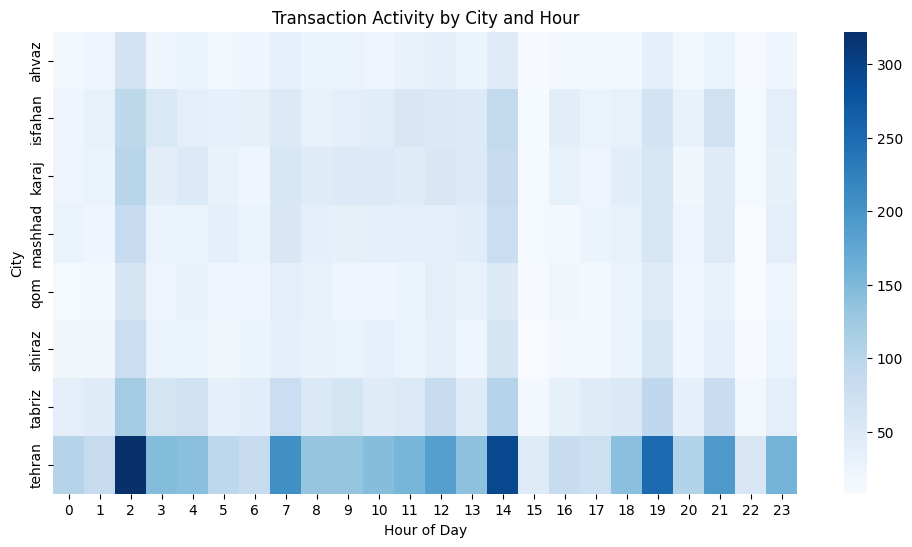

In [61]:
city_hour = pd.crosstab(df["city"], df["hour"])

plt.figure(figsize=(12, 6))
sns.heatmap(city_hour, cmap="Blues")
plt.title("Transaction Activity by City and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("City")
plt.show()

## Modeling Setup

Next, we use machine learning models to predict whether a transaction succeeds or fails.

The baseline model is a Decision Tree, and the advanced model is a Random Forest.

In [62]:
X = df[["card_type", "city", "amount", "hour"]]
y = df["status"]

X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(y)

X.head()

,amount,hour,card_type_discover,card_type_mastercard,card_type_visa,city_isfahan,city_karaj,city_mashhad,city_qom,city_shiraz,city_tabriz,city_tehran
0,1427657.0,10,False,False,True,False,False,False,False,False,False,True
1,1578078.0,13,False,True,False,False,False,False,False,False,False,True
2,250000.0,3,False,False,True,False,False,False,False,False,False,True
3,0.0,13,True,False,False,True,False,False,False,False,False,False
4,1782689.0,11,False,False,True,False,False,False,False,False,False,True


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8000
Testing rows: 2000


In [64]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_acc)

Decision Tree Accuracy: 0.508


In [65]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.498


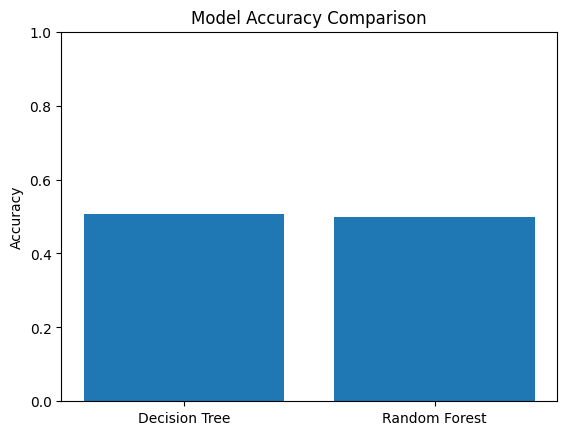

In [66]:
models = ["Decision Tree", "Random Forest"]
scores = [tree_acc, rf_acc]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Feature Importance

Feature importance shows which variables had the strongest influence in the Random Forest model.
This helps us understand which transaction features may matter most when identifying risky transaction behavior.

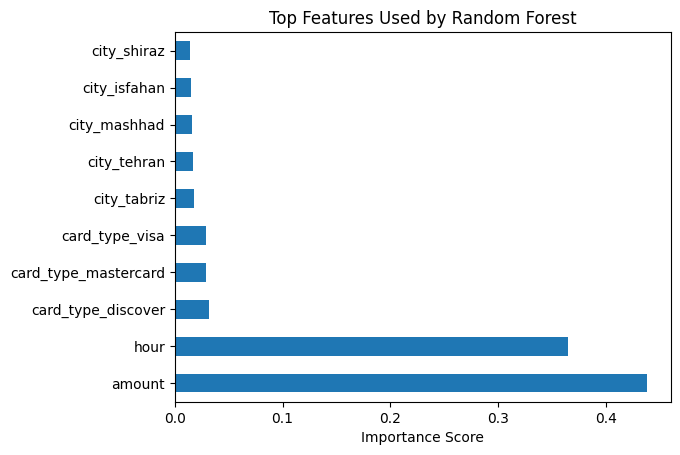

In [67]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

top_features.plot(kind="barh")
plt.title("Top Features Used by Random Forest")
plt.xlabel("Importance Score")
plt.show()

## Part 4 Conclusion

This modeling section shows that transaction amount, time, city, and card type can be used to test patterns related to transaction outcomes.

The p-values help show whether features have a relationship with transaction status, while the models test how well these features can predict outcomes.

The feature importance chart also helps connect the results back to our project question by showing which features had the most influence in identifying risky or dangerous transaction patterns.